# Cálculo dos Centroides

Para um cálculo mais adequado dos tempos de viagem nas operações de roteamento utilizando o R5Py, é interessante que os centroides de cada hexagono sejam deslocados a fim de estarem mais próximos das maiores concentrações de população nele contidas. De fato, cada hexágono até o momento contém contagens populacionais obitidas a partir dos setores censitários, conforme calculado no script A00. Contudo, essa istribuição interna pode não ser realemtne homogênea, sobretudo para as resoluções maiores. Para resolver esse problema, utiliza-se a grade estatística do IBGE, a qual detalha as populaçãoes em uma quadrícula de tamanho 200x200 m em áreas urbanas.

Com efeito, a partir de interpolações espaciais entre os hexágonos e a grade estatística, conforme detalhado abaixo, é possível encontrar o centro do hexágono a fim de obedecer as recomendações acima, derivadas de [Stępniak e Jacobs-Crisioni](https://doi.org/10.1016/j.jtrangeo.2017.04.001).

Deve ser salientdado, contudo, que a grade estatística disponível é apenas com relação ao censo de 2010: não há versão para 2022, de forma que não encontramos método seguro para fazer o ajuste dos centroides conforme o ano avança, sobretudo em regiões mais às margens do tecido urbano consolidado. Entendemos que qualquer técnica utilizada para gerar uma aproximação introduziria erros e imprecisões e não seria algo vantajoso: isso representaria um dispêndio de tempo e recursos para impactos que provavelmente seriam pouco significativos no modelo.

Por esse mesmo raciocínio, entendemos que utilizar os centroides conforme população de 2010 não seria problemático para os anos posteriores. Não obstante, ponderar os centroides, em vez de utilizar o centroide do hexagono (como utilizado nos modelos de automatos comuns para calcular a acessibilidade) traz como vantagem uma representação mais acurada do espaço urbano pelo menos nos anos de calibração [falar de artigos de pereira].



# Backend

In [1]:
import os
import pathlib
from typing import Union

import geopandas as gpd
import IPython.display as display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

pd.options.display.float_format = '{:,.2f}'.format

In [3]:
out_folder = os.environ.get('OUT_FOLDER')
out_folder = pathlib.Path(out_folder)

db = os.environ.get('DB_FOLDER')
db = pathlib.Path(db)

## INPUTS

In [4]:
inpath = out_folder / 'A/hexagonos.gpkg'

hexes = (
    gpd
    .read_file(inpath, layer='socioeconomico')
    .set_index([
        'name_muni',
        'code_muni',
        'ano',
        'aperture',
        'hex_id',
        ])
    )

In [5]:
hexes.head(3)

habitantes  \
name_muni      code_muni ano  aperture hex_id                        
Belo Horizonte 3106200   2014 9        89a881345b7ffff        0.87   
                                       89a88136103ffff      259.01   
                                       89a88136107ffff      311.04   

                                                        domicilios  \
name_muni      code_muni ano  aperture hex_id                        
Belo Horizonte 3106200   2014 9        89a881345b7ffff        0.27   
                                       89a88136103ffff       72.46   
                                       89a88136107ffff       86.66   

                                                        rendimento_medio  \
name_muni      code_muni ano  aperture hex_id                              
Belo Horizonte 3106200   2014 9        89a881345b7ffff          2,349.08   
                                       89a88136103ffff            658.08   
                                       89a88136107ffff            621.37   

                                                        ibeu  \
name_muni      code_muni ano  aperture hex_id                  
Belo Horizonte 3106200   2014 9        89a881345b7ffff  0.00   
                                       89a88136103ffff  0.87   
                                       89a88136107ffff  0.87   

                                                        quantidade_vinculos_ativos  \
name_muni      code_muni ano  aperture hex_id                                        
Belo Horizonte 3106200   2014 9        89a881345b7ffff                         NaN   
                                       89a88136103ffff                       13.00   
                                       89a88136107ffff                        6.00   

                                                        quantidade_estabelecimentos  \
name_muni      code_muni ano  aperture hex_id                                         
Belo Horizonte 3106200   2014 9        89a881345b7ffff                          NaN   
                                       89a88136103ffff                         5.00   
                                       89a88136107ffff                         1.00   

                                                                                                 geometry  
name_muni      code_muni ano  aperture hex_id                                                              
Belo Horizonte 3106200   2014 9        89a881345b7ffff  POLYGON ((619047.069 7806855.383, 619158.933 7...  
                                       89a88136103ffff  POLYGON ((617988.275 7803524.064, 618100.115 7...  
                                       89a88136107ffff  POLYGON ((617673.596 7803712.727, 617785.434 7...

# Grades Estatísticas

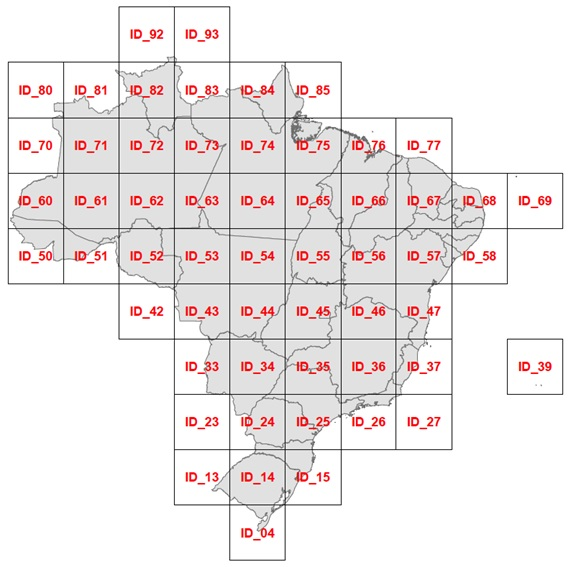

In [6]:
display.Image('https://wiki.openstreetmap.org/w/images/7/74/Articulacao.jpg')

In [7]:
# Helper functions to read and parse statistical grid

def _fix_zipped_path_to_shapes(inpath):
    try:
        return 'zip://' + inpath.as_posix()
    except AttributeError:
        return 'zip://' + inpath


def _reindex_grid(grid):
    d = {
        'ID_UNICO': 'cell_id',
        'POP': 'pop_total',
        'geometry': 'geometry'
        }
    return (
        grid.reindex(columns=d)
            .rename(columns=d)
            .set_index('cell_id')
        )


def _get_municipality_grid(path,
                           muni_name,
                           out_crs,
                           is_zipped):
    if is_zipped:
        inpath = _fix_zipped_path_to_shapes(path)
    
    gdf = (
        gpd.read_file(path)
           .to_crs(epsg=out_crs)
           .pipe(_reindex_grid)
        )
    
    gdf['name_muni'] = muni_name
    
    return gdf


def grid_by_municipality(inpaths,
                         out_crs=31983,
                         is_zipped=True):
    return pd.concat([
        _get_municipality_grid(path,
                               muni_name,
                               out_crs,
                               is_zipped)
        for muni_name, path
        in inpaths.items()
        ])
    

In [8]:
# Reads statistical grid

grid_files = {
    'belo_horizonte': 'grade_estatistica_id36.zip',
    }
inpaths = {
    k: db / 'census' / 'grade_estatistica' / v
    for k, v
    in grid_files.items()
    }
grid = grid_by_municipality(inpaths)

In [9]:
def filter_study_areas(grid, mask):
    return (
        grid.pipe(
                gpd.sjoin,
                mask.reset_index(),
                predicate='intersects',
                )
            .reset_index()
            .drop_duplicates(subset='cell_id')
            .drop(columns='index_right')
            .set_index('cell_id')
        
        )

In [10]:
grid = filter_study_areas(
    grid,
    hexes.xs(key=10, level='aperture')
    )

In [11]:
grid = grid.reindex(columns=['pop_total', 'geometry'])

In [12]:
grid.head(3)

,pop_total,geometry
cell_id,,
200ME60338N90882,345,"POLYGON ((597957.415 7790682.041, 597951.383 7..."
200ME60338N90884,597,"POLYGON ((597951.383 7790880.755, 597945.352 7..."
200ME60338N90886,497,"POLYGON ((597945.352 7791079.469, 597939.32 77..."


In [13]:
def compute_population_weighted_centroids(
    h3_gdf: gpd.GeoDataFrame,
    grid_gdf: gpd.GeoDataFrame,
    h3_id_col: str = "h3_id",
    grid_id_col: str = "grid_id",
    pop_col: str = "population",
    resolution_col: Union[str, None] = "resolution"
) -> gpd.GeoDataFrame:
    """
    Computes population-weighted centroids for H3 hexagons using
    population data from a statistical grid.
    """
    if resolution_col is not None and resolution_col in h3_gdf.columns:
        resolution_groups = h3_gdf.groupby(resolution_col)
        results = []

        for resolution_value, group in resolution_groups:
            interpolated = _compute_weighted_centroids_single_resolution(
                h3_gdf=group,
                grid_gdf=grid_gdf,
                h3_id_col=h3_id_col,
                grid_id_col=grid_id_col,
                pop_col=pop_col
            )
            results.append(interpolated)

        return pd.concat(results, ignore_index=True)

    return _compute_weighted_centroids_single_resolution(
        h3_gdf=h3_gdf,
        grid_gdf=grid_gdf,
        h3_id_col=h3_id_col,
        grid_id_col=grid_id_col,
        pop_col=pop_col
    )


def _compute_weighted_centroids_single_resolution(
    h3_gdf: gpd.GeoDataFrame,
    grid_gdf: gpd.GeoDataFrame,
    h3_id_col: str,
    grid_id_col: str,
    pop_col: str
) -> gpd.GeoDataFrame:
    """
    Computes population-weighted centroids for a single-resolution H3 GeoDataFrame
    using vectorized operations for improved performance.
    """
    h3_result = h3_gdf.copy()

    intersections = gpd.overlay(
        grid_gdf[[grid_id_col, pop_col, "geometry"]],
        h3_result[[h3_id_col, "geometry"]],
        how="intersection"
    )
    intersections["area"] = intersections.area

    intersections["fraction"] = (
        intersections["area"] /
        intersections.groupby(grid_id_col)["area"].transform("sum")
    )
    intersections["pop_share"] = intersections["fraction"] * intersections[pop_col]

    intersections["centroid_x"] = intersections.centroid.x
    intersections["centroid_y"] = intersections.centroid.y

    weighted_centroids = _vectorized_weighted_centroid(
        intersections, h3_id_col
    )

    return h3_result.merge(weighted_centroids, on=h3_id_col, how="left")


def _vectorized_weighted_centroid(
    intersections: pd.DataFrame,
    h3_id_col: str
) -> pd.DataFrame:
    """
    Computes population-weighted centroids using vectorized operations,
    safely handling zero-weight cases.
    """
    pop_share = intersections["pop_share"]

    grouped = intersections.groupby(h3_id_col).agg(
        weighted_x=("centroid_x", lambda x: _safe_weighted_avg(x, pop_share)),
        weighted_y=("centroid_y", lambda y: _safe_weighted_avg(y, pop_share))
    ).reset_index()

    return grouped


def _safe_weighted_avg(values, weights):
    w = weights.loc[values.index]
    total_weight = w.sum()
    if total_weight == 0:
        return np.average(values)
    return np.average(values, weights=w)


In [14]:
centroids = compute_population_weighted_centroids(
    h3_gdf=hexes.xs(key=2014, level='ano').reset_index(),
    grid_gdf=grid.reset_index(),
    h3_id_col="hex_id",
    grid_id_col="cell_id",
    pop_col="pop_total",
    resolution_col="aperture",
    )

In [15]:
centroids = (
    gpd
    .GeoDataFrame(
        centroids.drop(columns='geometry'),
        crs=31983,
        geometry=gpd.points_from_xy(
            centroids.weighted_x,
            centroids.weighted_y,
            )
        )
    .reindex(
        columns=[
            'hex_id',
            'aperture',
            'weighted_x',
            'weighted_y',
            'geometry',
        ]
    )
)

In [16]:
centroids.head()

,hex_id,aperture,weighted_x,weighted_y,geometry
0,89a881345b7ffff,9,"618,773.92","7,807,032.23",POINT (618773.916 7807032.228)
1,89a88136103ffff,9,"617,887.11","7,803,727.28",POINT (617887.107 7803727.275)
2,89a88136107ffff,9,"617,594.79","7,803,871.74",POINT (617594.787 7803871.74)
3,89a8813610bffff,9,"618,186.52","7,803,843.70",POINT (618186.524 7803843.704)
4,89a8813610fffff,9,"617,898.01","7,804,014.35",POINT (617898.014 7804014.346)


In [17]:
outpath = out_folder / 'A/pop_weighted_centroids.parquet'
centroids.to_parquet(outpath)